In [ ]:
from tqdm.auto import trange
import numpy as np
from numpy import pi as π
import matplotlib.pyplot as plt
import firedrake
from firedrake import inner, dx, exp, min_value, max_value, Constant, derivative
import irksome
import icepack
from icepack2.model import hybrid, mass_balance
from icepack.calculus import grad

In [2]:
def extract_surface(q_in):
    mesh_x = q_in.ufl_domain()._base_mesh
    shape = q_in.ufl_shape
    if len(shape) == 0:
        VLin = firedrake.FunctionSpace(q_in.ufl_domain(), "CG", 2, vfamily="CG", vdegree=1)
        q_targ = firedrake.Function(VLin).interpolate(q_in)
        element_xz = q_targ.ufl_element()
        if hasattr(element_xz, "factor_elements"):
            element_x = element_xz.factor_elements[0]
        else:
            element_x = element_xz.sub_elements[0]
    else:
        VLin = firedrake.VectorFunctionSpace(q_in.ufl_domain(), "CG", 2, dim=shape[0], vfamily="CG", vdegree=1)
        q_targ = firedrake.Function(VLin).interpolate(q_in)
        element_xz = q_targ.ufl_element()
        if hasattr(element_xz, "factor_elements"):
            element_hor = element_xz.factor_elements[0]
        else:
            element_hor = element_xz.sub_elements[0]
        if hasattr(element_hor, "factor_elements"):
            element_xy = element_hor.factor_elements[0]
        else:
            element_xy = element_hor.sub_elements[0]
        element_x = firedrake.VectorElement(element_xy, dim=shape[0])

    Q_x = firedrake.FunctionSpace(mesh_x, element_x)
    q_x = firedrake.Function(Q_x)
    if len(shape) > 0:
        q_x.dat.data[:] = q_targ.dat.data[1::2, :]
    else:
        q_x.dat.data[:] = q_targ.dat.data[1::2]
    return q_x


def extract_bed(q_in):
    mesh_x = q_in.ufl_domain()._base_mesh
    shape = q_in.ufl_shape
    if len(shape) == 0:
        VLin = firedrake.FunctionSpace(q_in.ufl_domain(), "CG", 2, vfamily="CG", vdegree=1)
        q_targ = firedrake.Function(VLin).interpolate(q_in)
        element_xz = q_targ.ufl_element()
        if hasattr(element_xz, "factor_elements"):
            element_x = element_xz.factor_elements[0]
        else:
            element_x = element_xz.sub_elements[0]
    else:
        VLin = firedrake.VectorFunctionSpace(q_in.ufl_domain(), "CG", 2, dim=shape[0], vfamily="CG", vdegree=1)
        q_targ = firedrake.Function(VLin).interpolate(q_in)
        element_xz = q_targ.ufl_element()
        if hasattr(element_xz, "factor_elements"):
            element_xy = element_xz.factor_elements[0].sub_elements[0]
        elif hasattr(element_xz.sub_elements[0], "factor_elements"):
            element_xy = element_xz.sub_elements[0].factor_elements[0]
        else:
            element_xy = element_xz.sub_elements[0].sub_elements[0]
        element_x = firedrake.VectorElement(element_xy, dim=shape[0])

    Q_x = firedrake.FunctionSpace(mesh_x, element_x)
    q_x = firedrake.Function(Q_x)
    if len(shape) > 0:
        q_x.dat.data[:] = q_targ.dat.data[::2, :]
    else:
        q_x.dat.data[:] = q_targ.dat.data[::2]
    return q_x

This notebook will demonstrate how to use the dual momentum balance model to simulate the evolution of a synthetic mountain glacier.
We'll start with a completely artificial initial glacier thickness, and then we'll spin it up to steady state.
The overall bed geometry is meant to mimic some of the features of Mt. Rainier in Washington State, but we'll produce a smaller glacier.
For many measurements, see [this volume](http://npshistory.com/publications/mora/glaciers-1963.pdf) from 1963, edited by Mark Meier and featuring many contributions by Austin Post.

Mt. Rainier has a circumference of about 150km, which works out to a radius of about 25km.
We'll use a computational domain about half that size.

In [3]:
radius = Constant(12e3)
mesh2d = firedrake.UnitDiskMesh(4)
mesh2d.coordinates.dat.data[:] *= float(radius)
mesh = firedrake.ExtrudedMesh(mesh2d, layers=1)

Next, we'll create some function spaces.
We'll use continuous linear finite elements for the basal elevation and discontinuous linear elements for the thickness.
In general, solving the mass balance equation for ice thickness tends to work much better with discontinuous elements.

In [4]:
cg1 = firedrake.FiniteElement("CG", "triangle", 1)
S = firedrake.FunctionSpace(mesh, cg1, vfamily="R", vdegree=0)
dg1 = firedrake.FiniteElement("DG", "triangle", 1)
Q = firedrake.FunctionSpace(mesh, dg1, vfamily="R", vdegree=0)

/Users/dlilien/sw/fd_3.14/venv-firedrake/lib/python3.14/site-packages/finat/ufl/elementlist.py:433: UserWarning: Discontinuous Lagrange element requested on triangle * interval, creating DQ element.
  warnings.warn("Discontinuous Lagrange element requested on %s, creating DQ element." % cell.cellname)


Mt. Rainier is about 4km high.
We'll use a bed topography of the form $B\exp(-|x|^2/r^2)$, although this is actually a little unrealistic.

In [5]:
x = firedrake.SpatialCoordinate(mesh)

B = Constant(4e3)
r_b = Constant(150e3 / (2 * π))
expr = B * exp(-(x[0]**2 + x[1]**2) / r_b**2)
b = firedrake.Function(S).interpolate(expr)

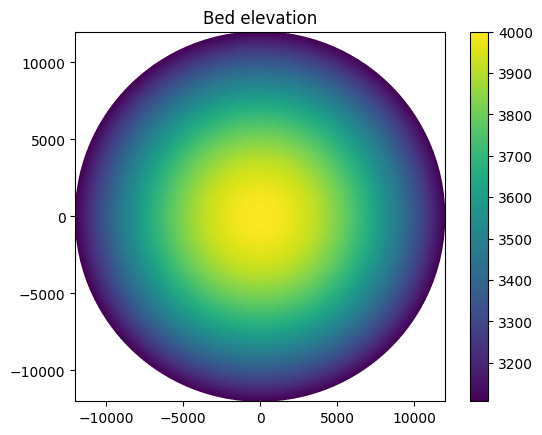

In [6]:
fig, ax = plt.subplots()
ax.set_aspect("equal")
ax.set_title("Bed elevation")
colors = firedrake.tripcolor(extract_bed(b), axes=ax)
firedrake.tricontour(extract_bed(b), levels=[1600.0, 2100.0], colors="black", axes=ax)
fig.colorbar(colors);

According to Meier and Post, at 1600m elevation, the surface mass balance is about -8.7 m/yr of water equivalent, and the equilibrium line altitude (where surface mass balance is zero) is at about 2100m elevation, and that the SMB must average about 0.7 m/yr above the ELA for the glacier to be in balance.
We'll use these as rough guidelines; trying to be too exact about it gives an accumulation field with a really dramatic change near the ELA that results in generalized numerical mayhem.
When we define the SMB field, we clamp the values at the top and bottom in order to avoid producing unrealistic values.
Not also how we have to convert one of the SMB values from meters of water equivalent to meters of ice equivalent by multiplying by 0.917.

In [7]:
z_measured = Constant(1600.0)
a_measured = Constant(-0.917 * 8.7)
a_top = Constant(0.7)
z_top = Constant(4e3)
δa_δz = (a_top - a_measured) / (z_top - z_measured)
a_max = Constant(0.7)

def smb(z):
    return min_value(a_max, a_measured + δa_δz * (z - z_measured))

We'll start with a very artificial initial guess for the thickness and evolve it toward equilibrium.

In [8]:
r_h = Constant(5e3)
H = Constant(100.0)
expr = H * max_value(0, 1 - inner(x, x) / r_h**2)
h = firedrake.Function(Q).interpolate(expr)
h_0 = h.copy(deepcopy=True)

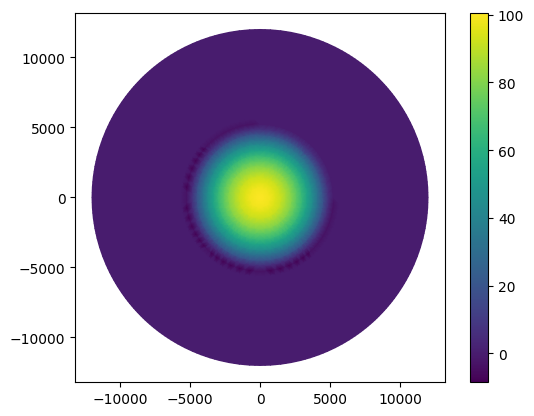

In [9]:
fig, ax = plt.subplots()
ax.set_aspect("equal")
colors = firedrake.tripcolor(extract_surface(h), axes=ax)
fig.colorbar(colors);

We can then compute the initial surface elevation and mass balance.

In [10]:
s = firedrake.Function(Q).interpolate(b + h)
a = firedrake.Function(Q).interpolate(smb(s))

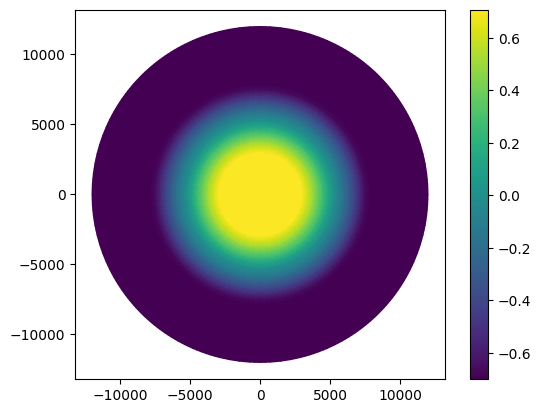

In [11]:
fig, ax = plt.subplots()
ax.set_aspect("equal")
colors = firedrake.tripcolor(extract_surface(a), vmin=-0.7, axes=ax)
fig.colorbar(colors);

In order to calculate the material properties of the glacier, we'll assume that it's roughly temperate, which isn't too far off from the truth.

In [12]:
from icepack2.constants import gravity, ice_density, glen_flow_law
A = icepack.rate_factor(Constant(273.15))

We'll use the shallow ice approximation, which diagnoses the velocity at a point in a purely local fashion using the thickness and surface slope, to initialize the ice velocity.

In [13]:
V = firedrake.VectorFunctionSpace(mesh, cg1, dim=2, vfamily="R", vdegree=0)

u = firedrake.Function(V)
v = firedrake.TestFunction(V)

ρ_I = Constant(ice_density)
g = Constant(gravity)
n = Constant(glen_flow_law)

P = ρ_I * g * h
S_n = inner(grad(s), grad(s))**((n - 1) / 2)
u_shear = -2 * A * P ** n / (n + 2) * h * S_n * grad(s)
F = inner(u - u_shear, v) * dx

solver_params = {"snes_type": "ksponly", "ksp_type": "gmres"}
fc_params = {"quadrature_degree": 6}
params = {"solver_parameters": solver_params, "form_compiler_parameters": fc_params}
firedrake.solve(F == 0, u, **params)

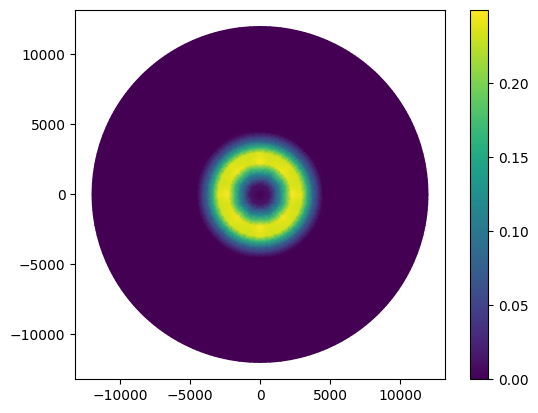

In [14]:
fig, ax = plt.subplots()
ax.set_aspect("equal")
colors = firedrake.tripcolor(extract_surface(u), axes=ax)
fig.colorbar(colors);

Now we'll get to the real modeling.
To proceed, we have to make function spaces to represent the membrane and basal stresses and create a variable that stores the velocity and stresses.
Here we use piecewise constant finite elements for the stresses.
In general, if you use $CG(k)$ elements for the velocity, you need to use $DG(k - 1)$ elements for the stresses.

In [15]:
vfamily = "GL"
vdegree = 2
V = firedrake.VectorFunctionSpace(mesh, "CG", 2, dim=2, vfamily=vfamily, vdegree=vdegree)
Σx = firedrake.TensorFunctionSpace(mesh, "DG", 1, shape=(2, 2), symmetry=True, vfamily=vfamily, vdegree=max(0, vdegree - 1))
T = firedrake.VectorFunctionSpace(mesh, "DG", 1, dim=2, vfamily=vfamily, vdegree=max(0, vdegree - 1))
T0 = firedrake.VectorFunctionSpace(mesh, "DG", 1, dim=2, vfamily="R", vdegree=0)
Z = V * Σx * T * T0
z = firedrake.Function(Z)

u = firedrake.Function(V).interpolate(u)
z.sub(0).assign(u);

This is a subtle but important point.
But we'll also want to regularize the momentum balance model a bit by pretending as if it were linear.
We chose some value of the ice fluidity $A$, which is fine, but remember that $A$ has units of strain rate $\times$ stress${}^{-n}$ where $n \approx 3$ is the Glen flow law exponent.
If we only change $n$ to 1 in the parts of the equation determining the constitutive relation but do nothing to $A$, the physical units that we use in the regularization will make no sense.
So what we do below is pick some arbitrary stress scale $\tau_c$, which here I'm taking to be 0.1 MPa or 100 kPa.
We're then choosing a strain rate scale $\dot\varepsilon_c$ so that $A = \dot\varepsilon_c \cdot\tau_c^{-n}$.
If we want to pretend like ice flow were linear, we could produce the right constitutive relation by then using the flow law coefficient $A' = \dot\varepsilon_c\cdot\tau_c^{-1}$ and all the units would make sense.

In [16]:
τ_c = Constant(0.1)
ε_c = Constant(A * τ_c ** n)

Now we're at the really important part.
To make the SSA model effectively do SIA, what we need is that, in the sliding law
$$K|\tau|^{m - 1}\tau = -u,$$
we take
$$K = \frac{hA}{n + 2}.$$
Now in order to make our regularization approach work, we also define the sliding coefficient as
$$K = u_c / \tau_c^m$$
where $\tau_c$ is a reference stress and $u_c$ a reference speed.
We're using the same reference stress for the flow and sliding laws of $\tau_c = $ 100 kPa, so we can then compute the reference speed as $u_c = K\tau_c^m$.
We can then add more sliding on top of the effective deformation that we use to mimic SIA.
To add some extra real sliding, we've increased the critical speed $u_c$ by a factor of 100 m/yr.

In [17]:
K = h * A / (n + 2)
U_c = Constant(100)
u_c = K * τ_c ** n + U_c

In [18]:
rheology = {
    "flow_law_exponent": n,
    "flow_law_coefficient": ε_c / τ_c ** n,
    "sliding_exponent": n,
    "sliding_coefficient": u_c / τ_c ** n,
}

u, M_x, M_z, τ_b = firedrake.split(z)

# Clamp the thickness from below in the momentum model. The hybrid strain-rate
# terms divide by thickness, so the raw (compact) initial thickness -- which is
# exactly zero outside the glacier -- makes the residual non-finite (NaN/Inf) at
# the very first evaluation, giving DIVERGED_FUNCTION_NANORINF.
h_min = Constant(1.0e1)
h_safe = max_value(h_min, h)

fields = {
    "velocity": u,
    "membrane_stress_x": M_x,
    "membrane_stress_z": M_z,
    "basal_stress": τ_b,
    "thickness": h_safe,
    "surface": s,
}

L = hybrid.HybridModel(calving_terminus=None).action(**fields, **rheology)
F = derivative(L, z)

For the solution procedure, we'll want to use a linearization of the problem where the thickness is clamped from below.

In [19]:
rfields = {
    "velocity": u,
    "membrane_stress_x": M_x,
    "membrane_stress_z": M_z,
    "basal_stress": τ_b,
    "thickness": h_safe,
    "surface": s,
}

L_r = hybrid.HybridModel(calving_terminus=None).action(**rfields, **rheology)
F_r = derivative(L_r, z)
J_r = derivative(F_r, z)

# Add a small amount of a *linearized* rheology to the Jacobian. The power-law
# (n = m = 3) Jacobian is singular wherever strain rates or basal stresses
# approach zero, which stalls Newton's method. Mixing in a linear term keeps
# the Jacobian well-conditioned.
linear_rheology = {
    "flow_law_exponent": 1,
    "flow_law_coefficient": ε_c / τ_c,
    "sliding_exponent": 1,
    "sliding_coefficient": u_c / τ_c,
}

α = Constant(0.01)
L_1 = hybrid.HybridModel(calving_terminus=None).action(**fields, **linear_rheology)
F_1 = derivative(L_1, z)
J_1 = derivative(F_1, z)
J = J_r + α * J_1

Observe below that, when we create the momentum balance problem, we want to find a zero of $F$ using a Newton-type method, but we're using the perturbation of $dF$ defined above in order to do the search.

In [20]:
degree = 1
qdegree = max(5, degree ** glen_flow_law)
pparams = {"form_compiler_parameters": {"quadrature_degree": qdegree}}
momentum_problem = firedrake.NonlinearVariationalProblem(F, z, J=J, **pparams)

Now we can see our initial value of the velocity.
Note how it's a different magnitude but similar shape to the SIA velocity.

In [21]:
sparams = {
    "snes_monitor": ":rainier-output.log",
    "snes_type": "newtonls",
    "snes_stol": 1.0e-4,
    "snes_atol": 1.0e-4,
    "snes_rtol": 1.0e-4,
    "snes_max_it": 250,
    "snes_divergence_tolerance": -1,
    "snes_linesearch_type": "nleqerr",
    "ksp_type": "preonly",
    "pc_type": "lu",
    "pc_factor_mat_solver_type": "mumps",
}

# This works but is 2x slower than the above.
fieldsplit_params = {
    "snes_type": "newtonls",
    "snes_linesearch_type": "nleqerr",  # or nleqerr or whatever doesn't break
    "snes_linesearch_max_it": 10,      # This is not the important knob for speed it seems
    "snes_stol": 1.0e-4,
    "snes_atol": 1.0e-4,
    "snes_rtol": 1.0e-4,
    "snes_max_it": 250,
    "snes_monitor": ":rainier-output.log",
    "ksp_type": "preonly",
    "pc_type": "fieldsplit",
    "pc_fieldsplit_type": "schur",
    "pc_fieldsplit_schur_fact_type": "full",
    "pc_fieldsplit_schur_precondition": "selfp",
    "pc_fieldsplit_0_fields": "1,2,3",   # membrane and basal stresses
    "pc_fieldsplit_1_fields": "0",     # velocity
    "fieldsplit_0": {
        "ksp_type": "preonly",
        "pc_type": "bjacobi",
    },
    "fieldsplit_1": {
        "ksp_type": "preonly",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
    },
}
momentum_solver = firedrake.NonlinearVariationalSolver(momentum_problem, solver_parameters=sparams)

In [22]:
num_continuation_steps = 5
for exponent in np.linspace(1.0, 3.0, num_continuation_steps):
    n.assign(exponent)
    momentum_solver.solve()

# Drop the linear Jacobian regularization now that we have a good starting
# guess. With α = 0 the Jacobian is exact. 
α.assign(0.0)

Constant([0.], name='constant_128', count=128)

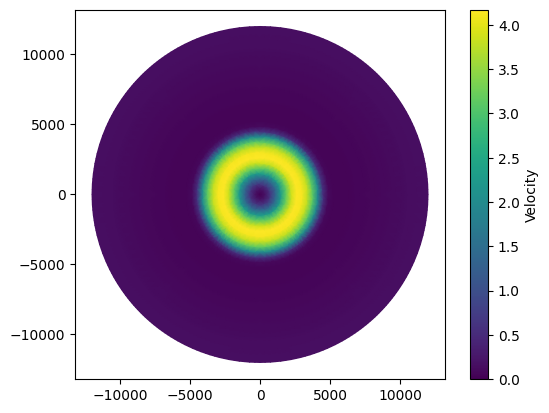

In [23]:
u, M_x, M_z, τ_b = z.subfunctions

fig, axes = plt.subplots()
axes.set_aspect("equal")
colors = firedrake.tripcolor(extract_surface(u), axes=axes)
fig.colorbar(colors, label="Velocity");

Let's zoom in and look at where the ELA falls.

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?


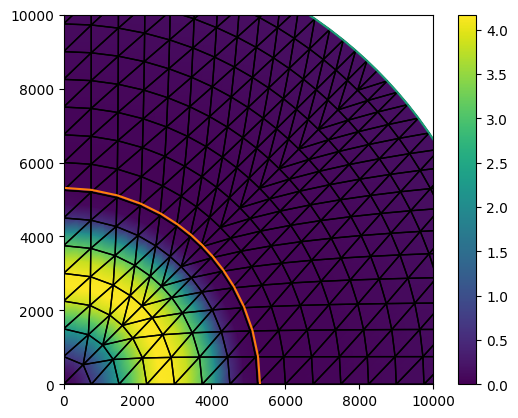

In [24]:
fig, axes = plt.subplots()
axes.set_aspect("equal")
axes.set_xlim((0, 10e3))
axes.set_ylim((0, 10e3))
colors = firedrake.tripcolor(extract_surface(u), axes=axes)
firedrake.triplot(mesh2d, axes=axes)
firedrake.tricontour(extract_surface(a), levels=[0, 1], colors="tab:orange", axes=axes)
fig.colorbar(colors);

Nowe we can form the mass balance equation.
We'll solve it using the backward Euler method.

In [25]:
G = mass_balance(thickness=h, velocity=u, accumulation=a)
tableau = irksome.BackwardEuler()
t = Constant(0.0)
dt = Constant(1.0 / 6)
sparams = {
    "solver_parameters": {
        "ksp_type": "gmres",
        "pc_type": "ilu",
    },
}
mass_solver = irksome.TimeStepper(G, tableau, t, dt, h, **sparams)

The good part: run the model for 50 years of simulation time. Note that the run is much shorter than SSA since it is significantly more expensive

In [ ]:
hs = [h.copy(deepcopy=True)]
us = [u.copy(deepcopy=True)]

final_time = 50.0
num_steps = int(final_time / float(dt))
for step in trange(num_steps):
    mass_solver.advance()
    h.interpolate(max_value(0, h))
    s.interpolate(b + h)
    a.interpolate(smb(s))

    # Fast path: exact Newton (α = 0). If a step fails, re-enable the linear
    # Jacobian regularization and re-run the exponent continuation from n = 1,
    # then turn the regularization back off.
    try:
        momentum_solver.solve()
    except firedrake.ConvergenceError:
        print("Convergence error")
        α.assign(0.01)
        for exponent in np.linspace(1.0, 3.0, num_continuation_steps):
            n.assign(exponent)
            momentum_solver.solve()
        α.assign(0.0)

    hs.append(h.copy(deepcopy=True))
    us.append(z.subfunctions[0].copy(deepcopy=True))

  0%|          | 0/300 [00:00<?, ?it/s]

Now let's make a movie of the evolution towards steady state.
The contour shows the final value of the ELA.

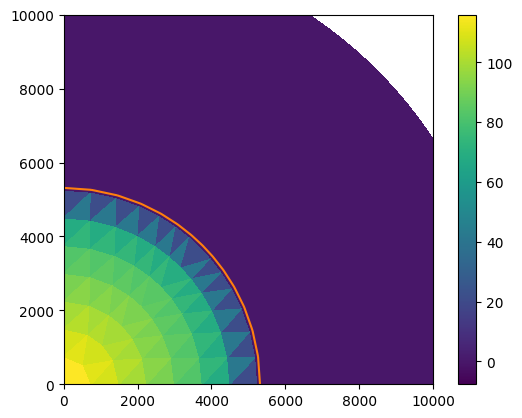

In [ ]:
fig, axes = plt.subplots()
axes.set_aspect("equal")
axes.set_xlim((0, 10e3))
axes.set_ylim((0, 10e3))
colors = firedrake.tripcolor(extract_surface(hs[-1]), num_sample_points=1, shading="flat", axes=axes)
firedrake.tricontour(extract_surface(a), levels=[0, 1], colors="tab:orange", axes=axes)
fig.colorbar(colors);

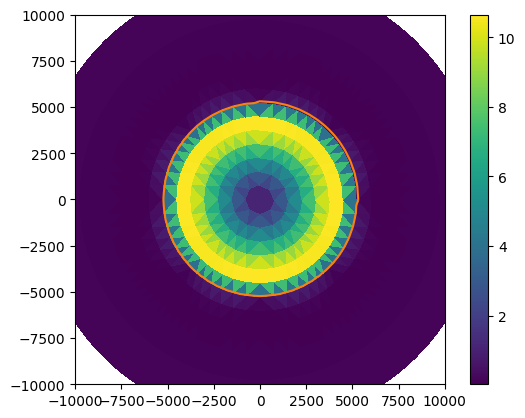

In [ ]:
u, M_x, M_z, τ_b = z.subfunctions

fig, axes = plt.subplots()
axes.set_aspect("equal")
axes.set_xlim((-10e3, 10e3))
axes.set_ylim((-10e3, 10e3))
colors = firedrake.tripcolor(extract_surface(u), num_sample_points=1, shading="flat", axes=axes)
firedrake.tricontour(extract_surface(a), levels=[0, 1], colors="tab:orange", axes=axes)
fig.colorbar(colors);

In [ ]:
%%capture

from matplotlib.animation import FuncAnimation

fig, axes = plt.subplots()
axes.set_aspect("equal")
axes.set_xlim((0, 10e3))
axes.set_ylim((0, 10e3))
colors = firedrake.tripcolor(extract_surface(hs[0]), vmax=130.0, num_sample_points=4, axes=axes)
fig.colorbar(colors)

fn_plotter = firedrake.FunctionPlotter(mesh2d, num_sample_points=4)
def animate(h):
    colors.set_array(fn_plotter(extract_surface(h)))

animation = FuncAnimation(fig, animate, hs, interval=1e3/60)

In [ ]:
from IPython.display import HTML
HTML(animation.to_html5_video())

Finally, let's check that the solver was working right.

In [ ]:
junk = "SNES Function norm"
with open("rainier-output.log", "r") as log_file:
    raw_data = [
        line.replace(junk, "").strip().split()
        for line in log_file.readlines()
    ]

convergence_log = [
    (int(iter_text), float(norm_text)) for iter_text, norm_text in raw_data
]

reduced_log = []
current_entry = []
for count, error in convergence_log:
    if count == 0:
        reduced_log.append(current_entry)
        current_entry = []

    current_entry.append(error)

reduced_log.pop(0);

First, we want to see that the number of Newton iterations was bounded.
If it starts reaching above 20 then you're probably in trouble.

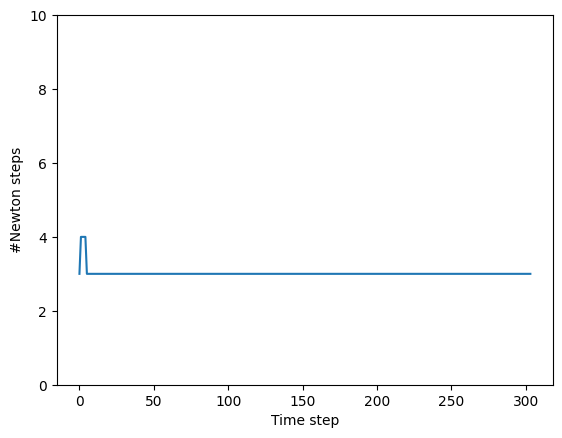

In [ ]:
fig, ax = plt.subplots()
ax.set_ylim((0, 10))
ax.set_xlabel("Time step")
ax.set_ylabel("#Newton steps")
ax.plot([len(entry) for entry in reduced_log]);

Next, we'll have a look at the initial and final residual values.
We used a convergence criterion where the iteration stops if the residual is reduced by more than something like $10^4$.
It would be cause for concern if the final value of the residual were edging upward, but this isn't the case.

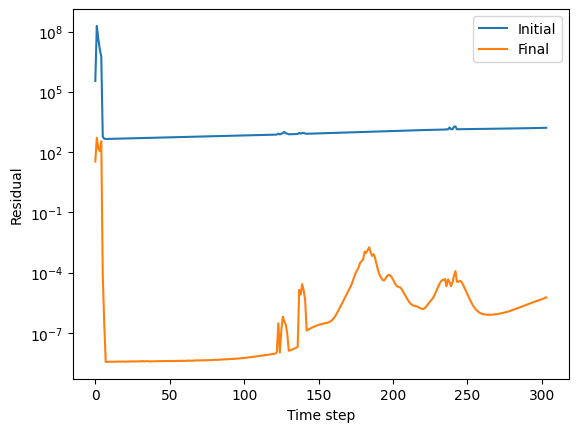

In [ ]:
fig, ax = plt.subplots()
ax.set_yscale("log")
ax.set_xlabel("Time step")
ax.set_ylabel("Residual")
ax.plot([entry[0] for entry in reduced_log], label="Initial")
ax.plot([entry[-1] for entry in reduced_log], label="Final")
ax.legend(loc="upper right");